/tmp/ipykernel_4699/3237107037.py:20: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
/tmp/ipykernel_4699/3237107037.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


<Figure size 1000x500 with 0 Axes>

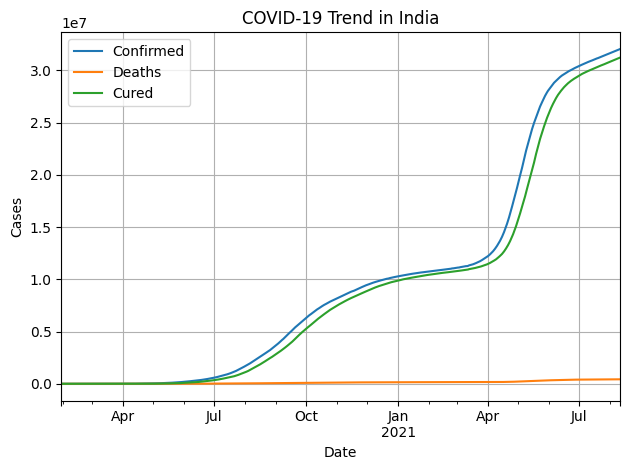

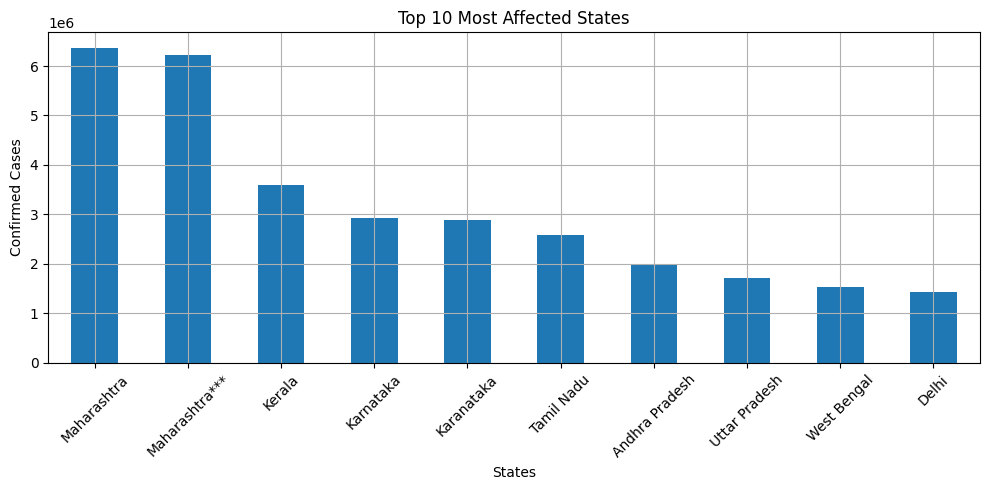

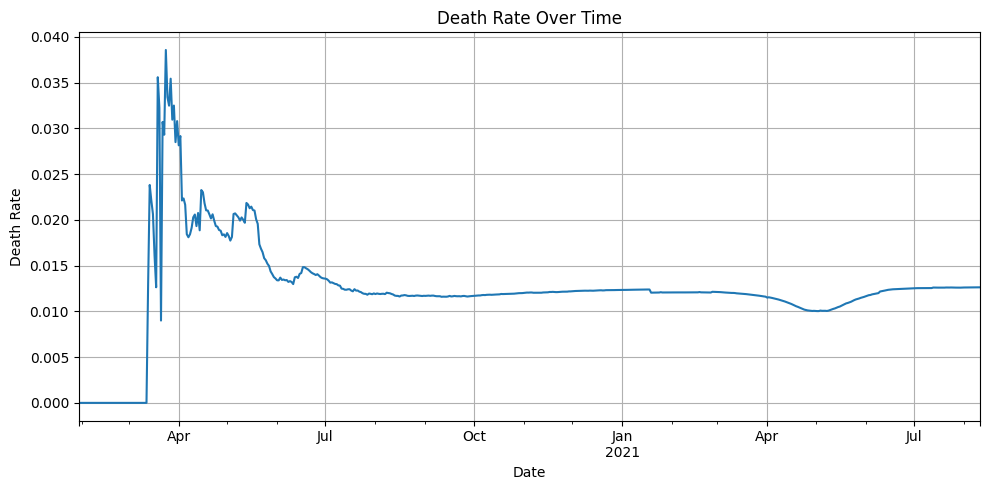

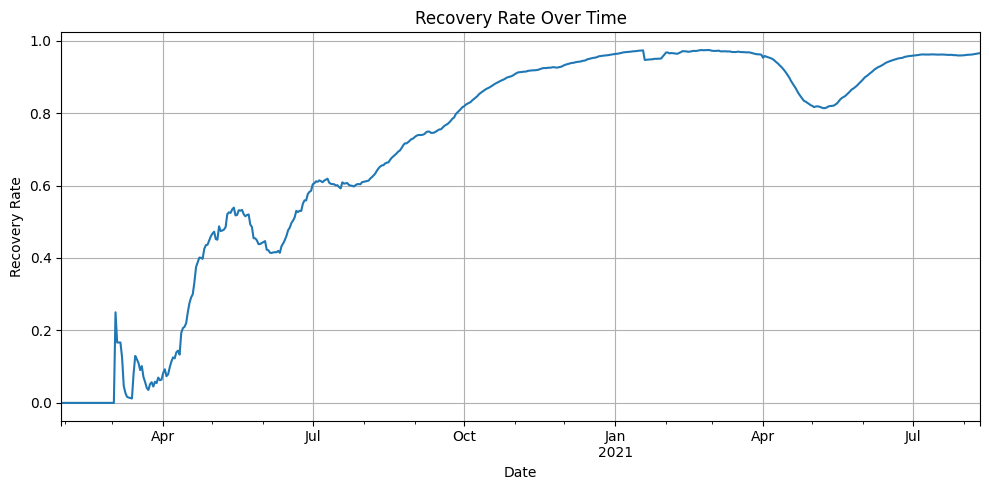


Correlation Matrix:
                     Sno     Cured    Deaths  Confirmed  Death Rate  \
Sno            1.000000  0.408482  0.301742   0.403012   -0.113298   
Cured          0.408482  1.000000  0.917529   0.997751    0.007463   
Deaths         0.301742  0.917529  1.000000   0.918346    0.078971   
Confirmed      0.403012  0.997751  0.918346   1.000000    0.009223   
Death Rate    -0.113298  0.007463  0.078971   0.009223    1.000000   
Recovery Rate  0.727065  0.268112  0.205346   0.260708   -0.131619   

               Recovery Rate  
Sno                 0.727065  
Cured               0.268112  
Deaths              0.205346  
Confirmed           0.260708  
Death Rate         -0.131619  
Recovery Rate       1.000000  


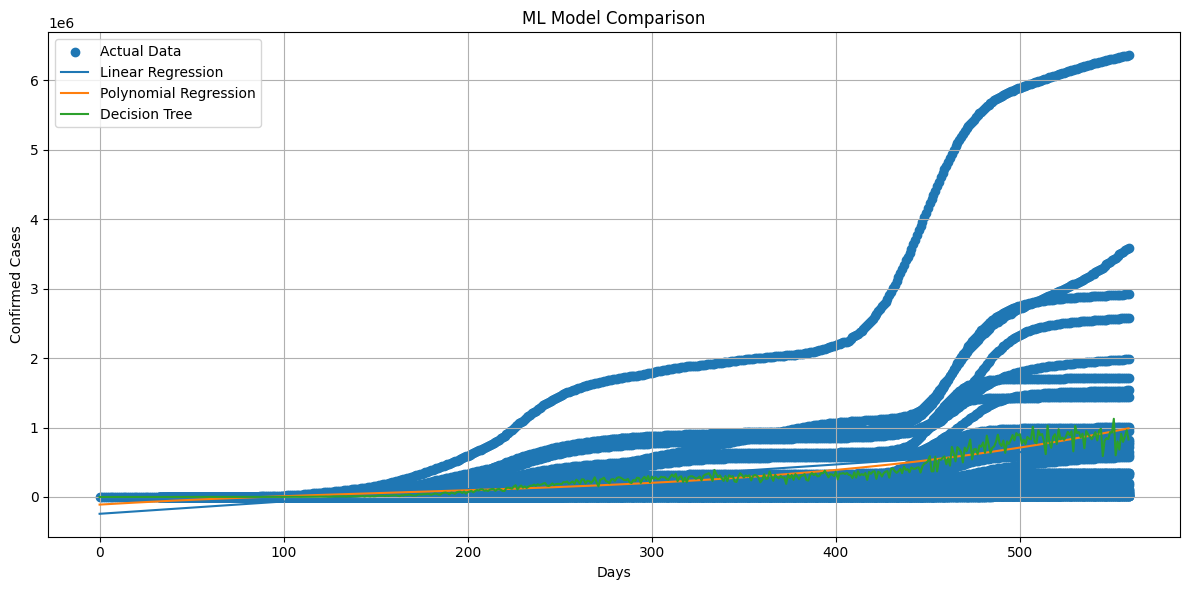


R2 Scores:
Linear Regression: 0.16696605254069286
Polynomial Regression: 0.18720310930865525
Decision Tree: 0.1410459770930892


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#  Load & Clean Data

df = pd.read_csv("/covid_19_india.csv")

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values(by='Date')

df = df.fillna(method='ffill')
df = df.drop_duplicates()

#  Feature Engineering

df['Death Rate'] = df['Deaths'] / df['Confirmed']
df['Recovery Rate'] = df['Cured'] / df['Confirmed']

# 1. COVID Trend Graph

daily_cases = df.groupby('Date')[['Confirmed', 'Deaths', 'Cured']].sum()

plt.figure(figsize=(10,5))
daily_cases.plot()
plt.title("COVID-19 Trend in India")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.grid()
plt.tight_layout()
plt.show()

# 2. Top 10 States

top_states = df.groupby('State/UnionTerritory')['Confirmed'].max() \
               .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title("Top 10 Most Affected States")
plt.xlabel("States")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

#  3. Death Rate Trend

plt.figure(figsize=(10,5))
df.groupby('Date')['Death Rate'].mean().plot()
plt.title("Death Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Death Rate")
plt.grid()
plt.tight_layout()
plt.show()

#  4. Recovery Rate Trend

plt.figure(figsize=(10,5))
df.groupby('Date')['Recovery Rate'].mean().plot()
plt.title("Recovery Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Recovery Rate")
plt.grid()
plt.tight_layout()
plt.show()

# 5. Correlation Matrix

corr_matrix = df.select_dtypes(include=np.number).corr()
print("\nCorrelation Matrix:\n", corr_matrix)

#  MACHINE LEARNING
# Convert Date to numeric
df['Days'] = (df['Date'] - df['Date'].min()).dt.days

X = df[['Days']]
y = df['Confirmed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Polynomial Regression
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)

# Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

# Model Visualization


df_sorted = df.sort_values(by='Days')

X_all = df_sorted[['Days']]
y_all = df_sorted['Confirmed']

y_lr = lr.predict(X_all)
y_poly = poly_model.predict(poly.transform(X_all))
y_dt = dt.predict(X_all)

plt.figure(figsize=(12,6))

plt.scatter(X_all, y_all, label="Actual Data")

plt.plot(X_all, y_lr, label="Linear Regression")
plt.plot(X_all, y_poly, label="Polynomial Regression")
plt.plot(X_all, y_dt, label="Decision Tree")

plt.xlabel("Days")
plt.ylabel("Confirmed Cases")
plt.title("ML Model Comparison")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Model Scores

print("\nR2 Scores:")
print("Linear Regression:", r2_score(y_test, lr.predict(X_test)))
print("Polynomial Regression:", r2_score(y_test_poly, poly_model.predict(X_test_poly)))
print("Decision Tree:", r2_score(y_test, dt.predict(X_test)))